In [ ]:
import pandas as pd

df_2022 = pd.read_parquet("../parquets/RW_LFS2022_reduced.parquet")
df_2023 = pd.read_parquet("../parquets/RW_LFS2023_reduced.parquet")
df_2024 = pd.read_parquet("../parquets/RW_LFS2024_reduced.parquet")

print(f"{len(df_2022)} rows, {df_2022.shape[1]} columns")
print(f"{len(df_2023)} rows, {df_2023.shape[1]} columns")
print(f"{len(df_2024)} rows, {df_2024.shape[1]} columns")

70424 rows, 170 columns
71849 rows, 170 columns
102562 rows, 170 columns


# Gender Comparison: Education & Employment (Rwanda LFS 2022–2024)

This analysis compares male and female outcomes across education and employment indicators using weighted survey data.

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Combine all years ──────────────────────────────────────────────────────────
df_2022["year"] = 2022
df_2023["year"] = 2023
df_2024["year"] = 2024

df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

# A01: 1 = Male, 2 = Female
df = df[df["A01"].isin([1, 2])].copy()
df["sex"] = df["A01"].map({1: "Male", 2: "Female"})

print(f"Combined dataset: {len(df):,} rows")
print(df.groupby("sex")["weight2"].sum().apply(lambda x: f"{x:,.0f}").rename("Weighted population"))


Combined dataset: 244,835 rows
sex
Female    20,760,636
Male      19,338,552
Name: Weighted population, dtype: object


## Education Comparison

In [14]:
def weighted_pct(df, condition, weight="weight2", by="sex"):
    """Return weighted % of rows meeting condition, grouped by `by`."""
    grp = df.groupby(by)
    num = grp.apply(lambda g: g.loc[condition(g), weight].sum())
    den = grp[weight].sum()
    return (num / den * 100).round(1)


# NOTE: B06 (literacy question) is not present in the reduced dataset.
# Literacy analysis is skipped; use indb1 (avg years of schooling) as a proxy.

# ── 1. Currently studying (B01 == 1) ─────────────────────────────────────────
studying_by_year = (
    df[df["B01"].notna()]
    .groupby(["year", "sex"])
    .apply(lambda g: (g.loc[g["B01"] == 1, "weight2"].sum() / g["weight2"].sum()) * 100)
    .round(1)
    .rename("Currently studying (%)")
    .reset_index()
    .pivot(index="year", columns="sex", values="Currently studying (%)")
)

print("=== Currently Studying (%) by Year and Sex ===")
print(studying_by_year.to_string())


# ── 2. Education level attained (attained) ────────────────────────────────────
edu_order = df["attained"].value_counts().index.tolist()

edu_dist = (
    df[df["attained"].notna()]
    .groupby(["sex", "attained"])["weight2"]
    .sum()
    .groupby(level=0, group_keys=False)
    .apply(lambda s: (s / s.sum() * 100).round(1))
    .rename("Share (%)")
    .reset_index()
    .pivot(index="attained", columns="sex", values="Share (%)")
    .fillna(0)
)

print("\n=== Education Level Distribution (%) ===")
print(edu_dist.to_string())


# ── 3. Average years of schooling (indb1) ─────────────────────────────────────
avg_school = (
    df[df["indb1"].notna()]
    .groupby(["year", "sex"])
    .apply(lambda g: np.average(g["indb1"], weights=g["weight2"]))
    .round(2)
    .rename("Avg years of schooling")
    .reset_index()
    .pivot(index="year", columns="sex", values="Avg years of schooling")
)

print("\n=== Average Years of Schooling by Year and Sex ===")
print(avg_school.to_string())


# ── 4. TVET attendance (TVT == 1) ─────────────────────────────────────────────
tvet_by_year = (
    df[df["TVT"].notna()]
    .groupby(["year", "sex"])
    .apply(lambda g: (g.loc[g["TVT"] == 1, "weight2"].sum() / g["weight2"].sum()) * 100)
    .round(1)
    .rename("TVET attendance (%)")
    .reset_index()
    .pivot(index="year", columns="sex", values="TVET attendance (%)")
)

print("\n=== TVET Attendance (%) by Year and Sex ===")
print(tvet_by_year.to_string())


/var/folders/_2/12_yd5k13j34v8mhrlwz176r0000gn/T/ipykernel_31750/3704379864.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g.loc[g["B01"] == 1, "weight2"].sum() / g["weight2"].sum()) * 100)


=== Currently Studying (%) by Year and Sex ===
sex   Female       Male
year                   
2022    17.1  18.799999
2023    13.8  16.100000
2024    14.5  16.400000

=== Education Level Distribution (%) ===
sex          Female       Male
attained                      
1.0       47.000000  46.000000
2.0       32.799999  32.400002
3.0        8.900000   8.700000
4.0        8.100000   8.400000
5.0        3.100000   4.400000


/var/folders/_2/12_yd5k13j34v8mhrlwz176r0000gn/T/ipykernel_31750/3704379864.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["indb1"], weights=g["weight2"]))



=== Average Years of Schooling by Year and Sex ===
sex   Female  Male
year              
2022    5.77  6.09
2023    5.65  5.96
2024    5.82  6.20

=== TVET Attendance (%) by Year and Sex ===
sex   Female       Male
year                   
2022    11.3  15.500000
2023    12.2  15.700000
2024    15.1  19.799999


/var/folders/_2/12_yd5k13j34v8mhrlwz176r0000gn/T/ipykernel_31750/3704379864.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g.loc[g["TVT"] == 1, "weight2"].sum() / g["weight2"].sum()) * 100)


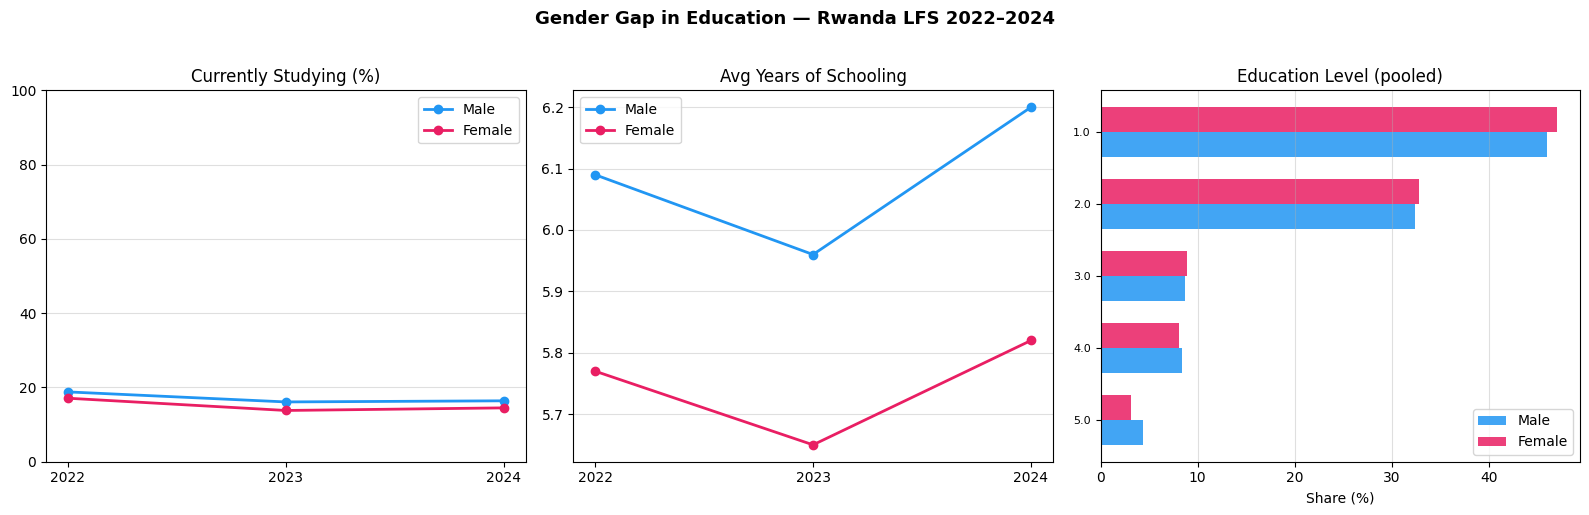

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
years = [2022, 2023, 2024]
colors = {"Male": "#2196F3", "Female": "#E91E63"}

# ── Currently studying trend ──────────────────────────────────────────────────
ax = axes[0]
for sex in ["Male", "Female"]:
    ax.plot(years, studying_by_year[sex], marker="o", label=sex, color=colors[sex], linewidth=2)
ax.set_title("Currently Studying (%)")
ax.set_xticks(years)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.4)

# ── Average years of schooling trend ─────────────────────────────────────────
ax = axes[1]
for sex in ["Male", "Female"]:
    ax.plot(years, avg_school[sex], marker="o", label=sex, color=colors[sex], linewidth=2)
ax.set_title("Avg Years of Schooling")
ax.set_xticks(years)
ax.legend()
ax.grid(axis="y", alpha=0.4)

# ── Education level distribution (pooled across years) ───────────────────────
ax = axes[2]
edu_plot = edu_dist.sort_values("Male", ascending=True)
y = np.arange(len(edu_plot))
h = 0.35
ax.barh(y - h/2, edu_plot["Male"], h, label="Male", color=colors["Male"], alpha=0.85)
ax.barh(y + h/2, edu_plot["Female"], h, label="Female", color=colors["Female"], alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(edu_plot.index, fontsize=8)
ax.set_xlabel("Share (%)")
ax.set_title("Education Level (pooled)")
ax.legend()
ax.grid(axis="x", alpha=0.4)

plt.suptitle("Gender Gap in Education — Rwanda LFS 2022–2024", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Employment Comparison

In [16]:
# ── Key labour market rates from derived variables (working-age pop only) ─────
# status1: Labour force status (16+); LFPR, UR1, employed16 are binary flags

wap = df[df["wap16"] == 1].copy()

def rate_by_year_sex(data, flag):
    return (
        data[data[flag].notna()]
        .groupby(["year", "sex"])
        .apply(lambda g: (g.loc[g[flag] == 1, "weight2"].sum() / g["weight2"].sum()) * 100)
        .round(1)
        .rename(flag)
        .reset_index()
        .pivot(index="year", columns="sex", values=flag)
    )

lfpr   = rate_by_year_sex(wap, "LFPR")
emp    = rate_by_year_sex(wap, "employed16")
unemp  = rate_by_year_sex(wap, "UR1")

print("=== Labour Force Participation Rate (%) — working-age 16+ ===")
print(lfpr.to_string())

print("\n=== Employment-to-Population Ratio (%) ===")
print(emp.to_string())

print("\n=== Unemployment Rate (%) ===")
print(unemp.to_string())


# ── Formal vs informal employment (IEV2) ──────────────────────────────────────
emp_df = wap[wap["IEV2"].notna()].copy()

formal_share = (
    emp_df.groupby(["year", "sex"])
    .apply(lambda g: (g.loc[g["IEV2"].astype(str).str.lower().str.contains("formal"), "weight2"].sum()
                      / g["weight2"].sum()) * 100)
    .round(1)
    .rename("Formal emp share (%)")
    .reset_index()
    .pivot(index="year", columns="sex", values="Formal emp share (%)")
)

print("\n=== Share in Formal Employment (%) ===")
print(formal_share.to_string())


# ── Occupation distribution (indd01 — ISCO high-level) ────────────────────────
occ_dist = (
    wap[wap["indd01"].notna()]
    .groupby(["sex", "indd01"])["weight2"]
    .sum()
    .groupby(level=0, group_keys=False)
    .apply(lambda s: (s / s.sum() * 100).round(1))
    .rename("Share (%)")
    .reset_index()
    .pivot(index="indd01", columns="sex", values="Share (%)")
    .fillna(0)
    .sort_values("Female", ascending=False)
)

print("\n=== Occupation Distribution (%) ===")
print(occ_dist.to_string())


# ── Mean monthly cash income for employees ────────────────────────────────────
income = (
    wap[wap["cash"].notna() & (wap["cash"] > 0)]
    .groupby(["year", "sex"])
    .apply(lambda g: np.average(g["cash"], weights=g["weight2"]))
    .round(0)
    .rename("Mean monthly income (RWF)")
    .reset_index()
    .pivot(index="year", columns="sex", values="Mean monthly income (RWF)")
)

print("\n=== Mean Monthly Cash Income (RWF) ===")
print(income.to_string())

gender_pay_gap = ((income["Male"] - income["Female"]) / income["Male"] * 100).round(1).rename("Gender pay gap (%)")
print("\n=== Gender Pay Gap (%, Male base) ===")
print(gender_pay_gap.to_string())


/var/folders/_2/12_yd5k13j34v8mhrlwz176r0000gn/T/ipykernel_31750/2488915512.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g.loc[g[flag] == 1, "weight2"].sum() / g["weight2"].sum()) * 100)
/var/folders/_2/12_yd5k13j34v8mhrlwz176r0000gn/T/ipykernel_31750/2488915512.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g.loc[g[flag] == 1, "weight2"].sum() / g["weight2"].sum()) *

=== Labour Force Participation Rate (%) — working-age 16+ ===
sex   Female  Male
year              
2022     0.0   0.0
2023     0.0   0.0
2024     0.0   0.0

=== Employment-to-Population Ratio (%) ===
sex   Female  Male
year              
2022     0.0   0.0
2023     0.0   0.0
2024     0.0   0.0

=== Unemployment Rate (%) ===
sex   Female  Male
year              
2022     0.0   0.0
2023     0.0   0.0
2024     0.0   0.0

=== Share in Formal Employment (%) ===
sex   Female  Male
year              
2022     0.0   0.0
2023     0.0   0.0
2024     0.0   0.0

=== Occupation Distribution (%) ===
sex        Female  Male
indd01                 
9.0     59.599998  54.0
5.0     20.500000  14.0
6.0      6.300000   5.8
2.0      6.100000   6.5
7.0      4.700000  11.1
4.0      1.100000   0.7
1.0      0.800000   1.3
3.0      0.700000   1.5
8.0      0.100000   5.1

=== Mean Monthly Cash Income (RWF) ===
sex    Female     Male
year                  
2022  41651.0  72165.0
2023  50627.0  83162.0
2024  5440

/var/folders/_2/12_yd5k13j34v8mhrlwz176r0000gn/T/ipykernel_31750/2488915512.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g.loc[g["IEV2"].astype(str).str.lower().str.contains("formal"), "weight2"].sum()
/var/folders/_2/12_yd5k13j34v8mhrlwz176r0000gn/T/ipykernel_31750/2488915512.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["cash"], weights=g["weight2"]))


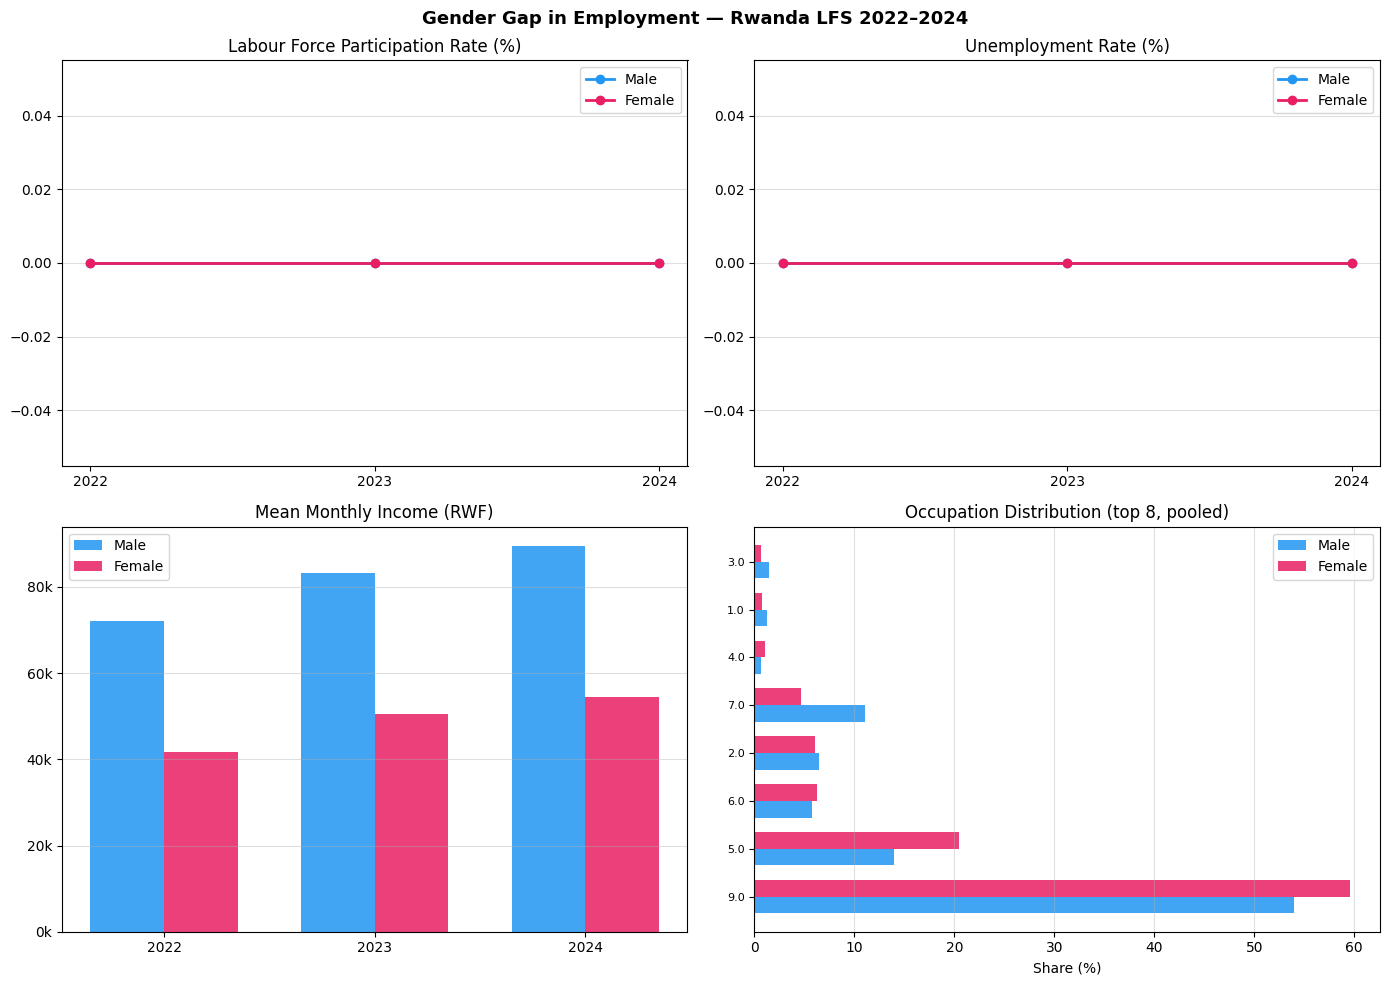

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── LFPR trend ────────────────────────────────────────────────────────────────
ax = axes[0, 0]
for sex in ["Male", "Female"]:
    ax.plot(years, lfpr[sex], marker="o", label=sex, color=colors[sex], linewidth=2)
ax.set_title("Labour Force Participation Rate (%)")
ax.set_xticks(years)
ax.legend(); ax.grid(axis="y", alpha=0.4)

# ── Unemployment rate trend ───────────────────────────────────────────────────
ax = axes[0, 1]
for sex in ["Male", "Female"]:
    ax.plot(years, unemp[sex], marker="o", label=sex, color=colors[sex], linewidth=2)
ax.set_title("Unemployment Rate (%)")
ax.set_xticks(years)
ax.legend(); ax.grid(axis="y", alpha=0.4)

# ── Mean income trend ─────────────────────────────────────────────────────────
ax = axes[1, 0]
x = np.arange(len(years))
w = 0.35
ax.bar(x - w/2, income["Male"],   w, label="Male",   color=colors["Male"],   alpha=0.85)
ax.bar(x + w/2, income["Female"], w, label="Female", color=colors["Female"], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(years)
ax.set_title("Mean Monthly Income (RWF)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.legend(); ax.grid(axis="y", alpha=0.4)

# ── Occupation distribution (top 8) ──────────────────────────────────────────
ax = axes[1, 1]
occ_top = occ_dist.head(8)
y = np.arange(len(occ_top))
h = 0.35
ax.barh(y - h/2, occ_top["Male"],   h, label="Male",   color=colors["Male"],   alpha=0.85)
ax.barh(y + h/2, occ_top["Female"], h, label="Female", color=colors["Female"], alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(occ_top.index, fontsize=8)
ax.set_xlabel("Share (%)")
ax.set_title("Occupation Distribution (top 8, pooled)")
ax.legend(); ax.grid(axis="x", alpha=0.4)

plt.suptitle("Gender Gap in Employment — Rwanda LFS 2022–2024", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
